# Imports

In [9]:
import kagglehub
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Phase 1: Loading, Splitting and EDA
Load the data from kaggle. Split the data into train, validation and test subsets. The test data should have at least 100 fraud transactions. Examine the dataset structure. Analyze distributions and detect potential data imbalances. Normalize or standardize the dataset. Handle missing or irrelevant features if necessary. Plots different data representations and print necessary information to show your efforts in this part.


In [2]:
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

100%|██████████| 66.0M/66.0M [01:15<00:00, 915kB/s] 

Extracting files...


Path to dataset files: C:\Users\reda\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [7]:
# Construct the full path to the CSV file
csv_file_path = os.path.join(path, "creditcard.csv")

# Load the CSV into a Pandas DataFrame
df = pd.read_csv(csv_file_path)

## EDA

In [10]:
# 1. Basic Structure
print("--- Dataset Info ---")
df.info()

# 2. Statistical Summary
print("\n--- Statistical Summary ---")
# Only showing Time, Amount, and Class for brevity, but it calculates for all
print(df[['Time', 'Amount', 'Class']].describe()) 

# 3. Check for Missing Values
print("\n--- Missing Values ---")
missing_values = df.isnull().sum().max()
if missing_values == 0:
    print("No missing values found in the dataset.")
else:
    print(df.isnull().sum()[df.isnull().sum() > 0])

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  

Normal Transactions: 284315 (99.827%)
Fraud Transactions: 492 (0.173%)


C:\Users\reda\AppData\Local\Temp\ipykernel_4892\1355743648.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['#1f77b4', '#d62728'])


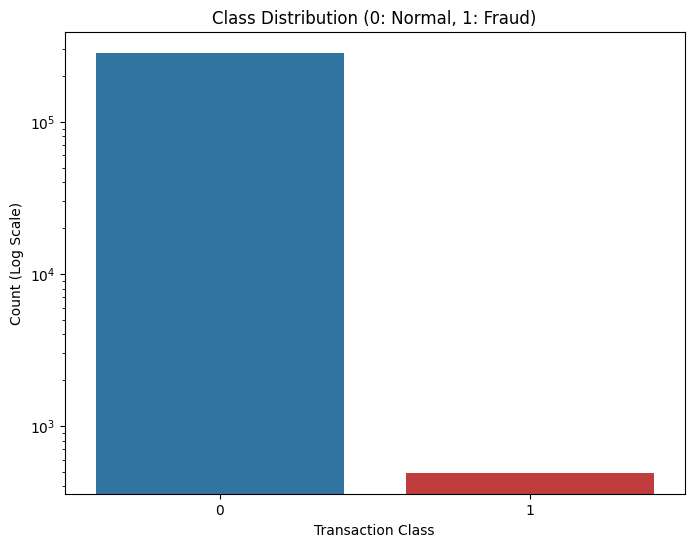

In [11]:
# Calculate exact counts and percentages
normal_transactions = len(df[df['Class'] == 0])
fraud_transactions = len(df[df['Class'] == 1])
total_transactions = len(df)

print(f"Normal Transactions: {normal_transactions} ({round((normal_transactions/total_transactions)*100, 3)}%)")
print(f"Fraud Transactions: {fraud_transactions} ({round((fraud_transactions/total_transactions)*100, 3)}%)")

# Plot the imbalance
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df, palette=['#1f77b4', '#d62728'])
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.yscale('log') # Using a log scale because the imbalance is so extreme
plt.ylabel('Count (Log Scale)')
plt.xlabel('Transaction Class')
plt.show()

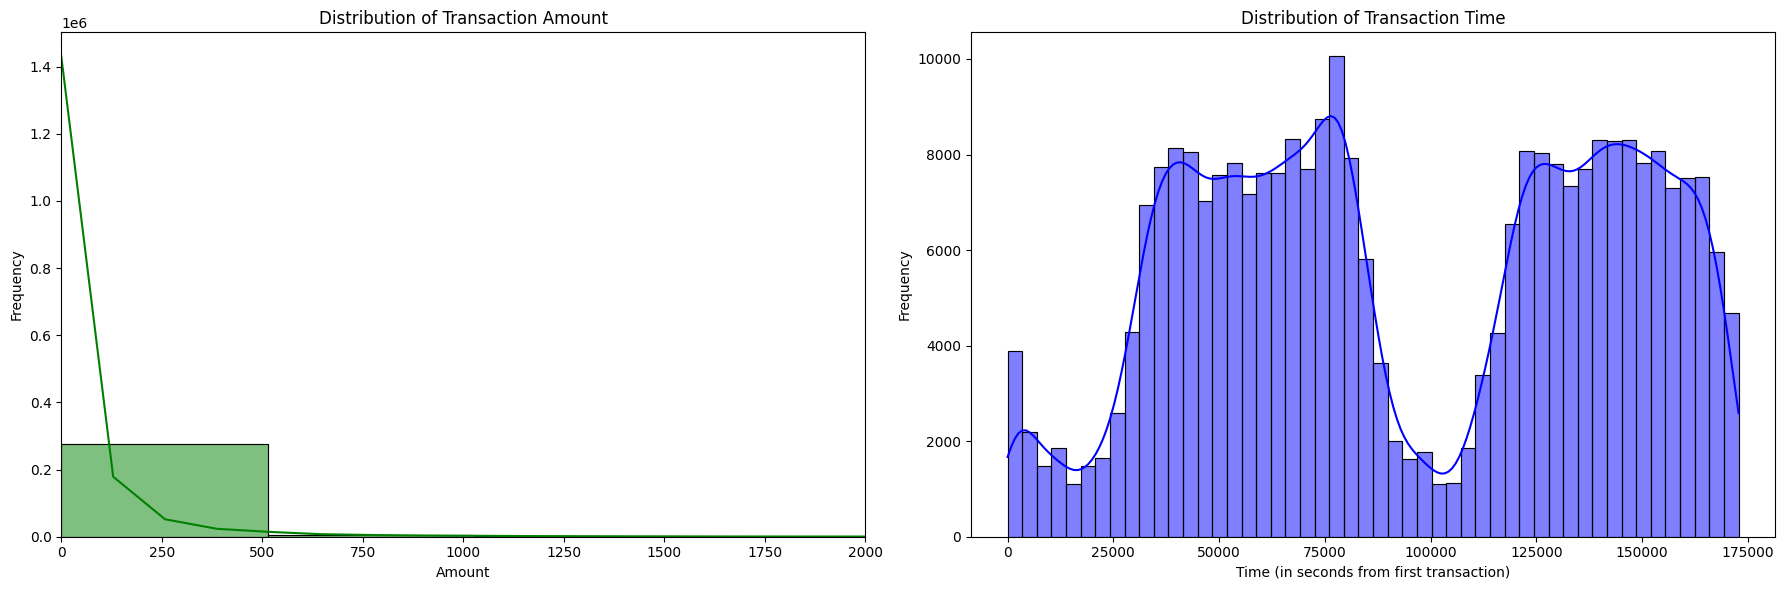

In [12]:
# Set up a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot the distribution of the 'Amount' feature
sns.histplot(df['Amount'], bins=50, ax=axes[0], color='green', kde=True)
axes[0].set_title('Distribution of Transaction Amount')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim([min(df['Amount']), 2000]) # Zooming in to see the bulk of the data

# Plot the distribution of the 'Time' feature
sns.histplot(df['Time'], bins=50, ax=axes[1], color='blue', kde=True)
axes[1].set_title('Distribution of Transaction Time')
axes[1].set_xlabel('Time (in seconds from first transaction)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

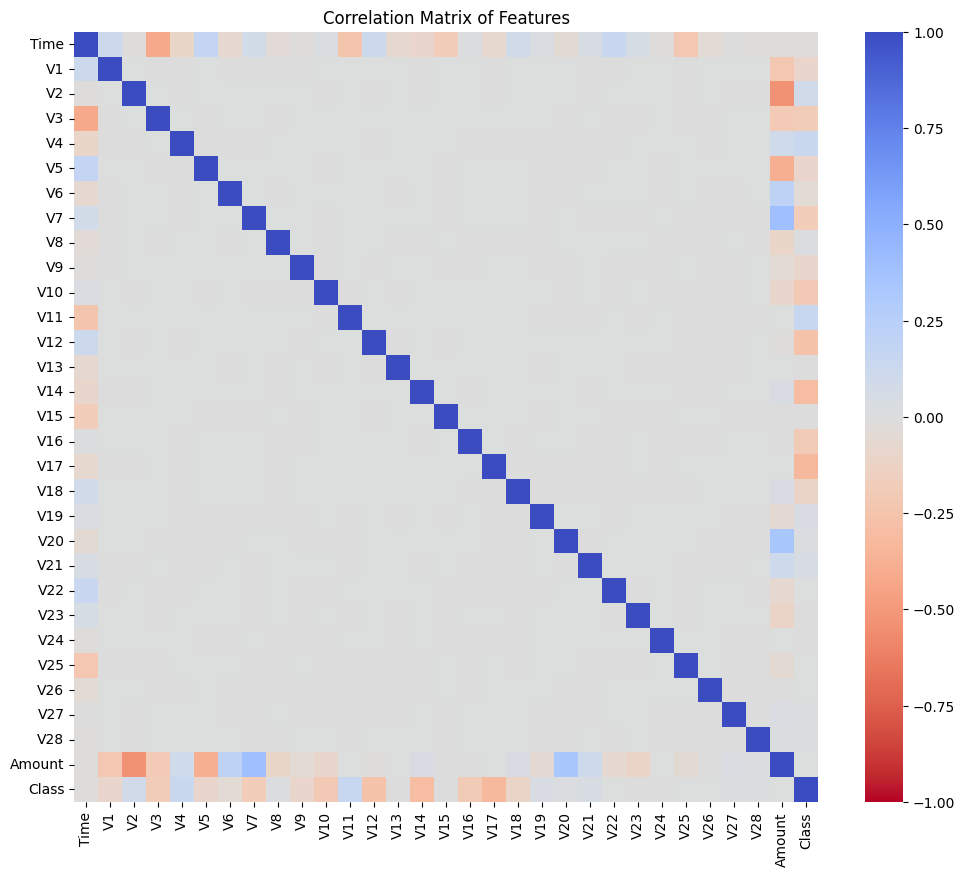

In [13]:
plt.figure(figsize=(12, 10))
# Calculate correlations
corr = df.corr()

# Create a heatmap
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Features')
plt.show()

## Train-Test-split

In [6]:
# Separate the features (X) from the target label (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 1. Isolate the Test Set (25% of total data)
# stratify=y ensures the class distribution is maintained.
# 25% of 492 > 100
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# 2. Split the remaining 75% into Training and Validation sets
# test_size=0.20 here means 20% of the *remaining* data goes to Validation.
# This results in a final split of roughly 60% Train, 15% Validation, 25% Test.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, stratify=y_temp, random_state=42
)

# 3. Verification
print("--- Split Verification ---")
print(f"Total Fraud in Test Set: {y_test.sum()} (Requirement: >= 100)")
print(f"Total Fraud in Validation Set: {y_val.sum()}")
print(f"Total Fraud in Training Set: {y_train.sum()}")
print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Validation set size: {X_val.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

--- Split Verification ---
Total Fraud in Test Set: 123 (Requirement: >= 100)
Total Fraud in Validation Set: 74
Total Fraud in Training Set: 295

Training set size: 170884 rows
Validation set size: 42721 rows
Test set size: 71202 rows


In [ ]:
#! [shadi] I DONT AGREE WITH THIS
# # Drop the 'Time' column as it is irrelevant for distance-based anomaly detection
# X_train = X_train.drop(['Time'], axis=1)
# X_val = X_val.drop(['Time'], axis=1)
# X_test = X_test.drop(['Time'], axis=1)

# print("Dropped 'Time' feature from all subsets.")